# Laboratorio 7 — Spark MLlib
## 02. Estadística descriptiva, exploración y correlaciones

Se trabaja con la población analítica de **2025** (`data/processed/personas_2025.parquet`): personas de 15 años o más, ocupadas, asalariadas y con salario positivo registrado.

- Las estadísticas, los percentiles y las correlaciones se calculan con **todos** los registros de 2025 en Spark.
- A pandas solo pasan tablas agregadas (conteos, histogramas ya agrupados).
- Los resultados describen los registros analizados; no son estimaciones oficiales de la población guatemalteca (análisis no ponderado).

In [1]:
import sys
from pathlib import Path

RAIZ = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(RAIZ))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config, exploracion

pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

config.FIGURES.mkdir(parents=True, exist_ok=True)
config.TABLES.mkdir(parents=True, exist_ok=True)

spark = config.crear_spark("lab7_02_exploracion")
spark.sparkContext.setLogLevel("ERROR")

df = spark.read.parquet(str(config.DATA_PROCESSED / "personas_2025.parquet")).persist()
print("Registros de la población analítica 2025:", f"{df.count():,}")

26/09/24 16:46:01 WARN Utils: Your hostname, MacBook-Pro-de-Joel-2.local resolves to a loopback address: 127.0.0.1; using 192.168.0.20 instead (on interface en0)
26/09/24 16:46:01 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/09/24 16:46:01 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Registros de la población analítica 2025: 53,025


## 1. Estadística descriptiva

Cantidad de observaciones, media, mediana, desviación estándar, mínimo, máximo y percentiles 25, 75 y 95 de las cuatro variables numéricas. Los percentiles son exactos, no aproximados.

In [2]:
desc = exploracion.descriptivas(df)
desc.index = [exploracion.ETIQUETAS[v] for v in desc.index]
desc.to_csv(config.TABLES / "02_descriptivas_2025.csv")
desc

,n,media,mediana,desv_estandar,minimo,maximo,p25,p75,p95
Salario mensual (Q),53025,"3,421.68","3,000.00","2,902.11",1.00,"99,000.00","1,800.00","4,000.00","8,000.00"
Edad (años),53025,35.19,33.00,13.52,15.00,89.00,24.00,44.00,61.00
Antigüedad (años),53025,5.56,2.00,7.83,0.00,70.00,0.50,7.00,22.00
Horas semanales,53025,46.31,45.00,18.63,1.00,126.00,40.00,55.00,80.00


In [3]:
d = exploracion.descriptivas(df)
s = d.loc["salario_mensual"]
print(f"Salario: mediana Q{s['mediana']:,.0f}, media Q{s['media']:,.0f}, P95 Q{s['p95']:,.0f}, máximo Q{s['maximo']:,.0f}.")
print(f"El 5 % con mayores salarios gana más de Q{s['p95']:,.0f}; el máximo es {s['maximo'] / s['mediana']:.1f} veces la mediana.")
for v in ["edad", "antiguedad", "horas_semanales"]:
    r = d.loc[v]
    print(f"{exploracion.ETIQUETAS[v]}: mediana {r['mediana']:.1f}, rango intercuartílico {r['p25']:.1f} a {r['p75']:.1f}, máximo {r['maximo']:.1f}.")

Salario: mediana Q3,000, media Q3,422, P95 Q8,000, máximo Q99,000.
El 5 % con mayores salarios gana más de Q8,000; el máximo es 33.0 veces la mediana.
Edad (años): mediana 33.0, rango intercuartílico 24.0 a 44.0, máximo 89.0.
Antigüedad (años): mediana 2.0, rango intercuartílico 0.5 a 7.0, máximo 70.0.
Horas semanales: mediana 45.0, rango intercuartílico 40.0 a 55.0, máximo 126.0.


**Interpretación.** Los 53,025 registros de 2025 tienen un salario mediano de **Q3,000** y medio de **Q3,422**; la mitad central gana entre Q1,800 y Q4,000 y el 5 % más alto supera los Q8,000. El máximo (Q99,000) es 33 veces la mediana y la desviación estándar (Q2,902) es casi tan grande como la media: la dispersión viene de una cola de salarios altos. La edad mediana es 33 años (24 a 44). La antigüedad es muy asimétrica: mediana de 2 años frente a una media de 5.6 y un máximo de 70, es decir, la mayoría lleva poco tiempo en su empleo y unos pocos llevan décadas. La jornada mediana es de 45 horas (40 a 55), con un 5 % que trabaja 80 horas o más.

## 2. Distribución de los registros por categoría ocupacional, nivel educativo y dominio

Los códigos se muestran tal como vienen en las bases; la categoría ocupacional se rotula con su significado.

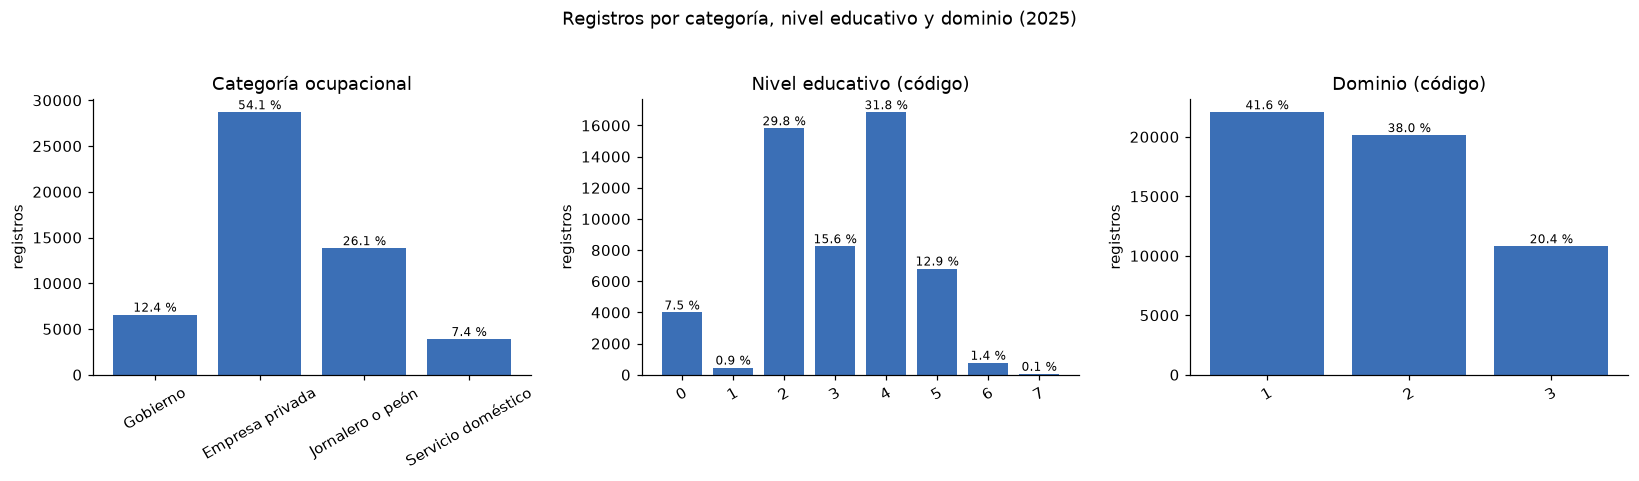

In [4]:
CATEGORIAS = {"1": "Gobierno", "2": "Empresa privada", "3": "Jornalero o peón", "4": "Servicio doméstico"}

def rotular(tabla, mapa=None, prefijo=""):
    t = tabla.copy()
    t["etiqueta"] = [mapa.get(c, c) if mapa else (c if c == config.DESCONOCIDO else f"{prefijo}{c}") for c in t["categoria"]]
    return t

conteos = {
    "Categoría ocupacional": rotular(exploracion.conteo_categorias(df, "categoria_ocupacional"), CATEGORIAS),
    "Nivel educativo (código)": rotular(exploracion.conteo_categorias(df, "nivel_educativo")),
    "Dominio (código)": rotular(exploracion.conteo_categorias(df, "dominio")),
}

fig, ejes = plt.subplots(1, 3, figsize=(15, 4.2))
for eje, (titulo, t) in zip(ejes, conteos.items()):
    barras = eje.bar(t["etiqueta"], t["registros"], color="#3B6FB6")
    for b, p in zip(barras, t["porcentaje"]):
        eje.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{p:.1f} %", ha="center", va="bottom", fontsize=8)
    eje.set_title(titulo)
    eje.set_ylabel("registros")
    eje.tick_params(axis="x", rotation=30)
fig.suptitle("Registros por categoría, nivel educativo y dominio (2025)", y=1.03)
plt.tight_layout()
plt.savefig(config.FIGURES / "02_distribucion_categorias.png", dpi=120, bbox_inches="tight")
plt.show()

In [5]:
for titulo, t in conteos.items():
    mayor = t.loc[t["registros"].idxmax()]
    menor = t.loc[t["registros"].idxmin()]
    print(f"{titulo}: la categoría más frecuente es '{mayor['etiqueta']}' ({mayor['porcentaje']:.1f} %) y la menos frecuente '{menor['etiqueta']}' ({menor['porcentaje']:.1f} %).")
pd.concat({k: v[["etiqueta", "registros", "porcentaje"]].set_index("etiqueta") for k, v in conteos.items()})

Categoría ocupacional: la categoría más frecuente es 'Empresa privada' (54.1 %) y la menos frecuente 'Servicio doméstico' (7.4 %).
Nivel educativo (código): la categoría más frecuente es '4' (31.8 %) y la menos frecuente '7' (0.1 %).
Dominio (código): la categoría más frecuente es '1' (41.6 %) y la menos frecuente '3' (20.4 %).


registros  porcentaje
                         etiqueta                                 
Categoría ocupacional    Gobierno                 6575       12.40
                         Empresa privada         28702       54.13
                         Jornalero o peón        13842       26.10
                         Servicio doméstico       3906        7.37
Nivel educativo (código) 0                        3995        7.53
                         1                         459        0.87
                         2                       15822       29.84
                         3                        8249       15.56
                         4                       16851       31.78
                         5                        6818       12.86
                         6                         771        1.45
                         7                          60        0.11
Dominio (código)         1                       22072       41.63
                         2                       20146       37.99
                         3                       10807       20.38

**Interpretación.** Más de la mitad de los registros son empleados de **empresa privada (54.1 %)**, seguidos por jornaleros o peones (26.1 %), empleados de gobierno (12.4 %) y servicio doméstico (7.4 %). En educación, los códigos **4 (31.8 %) y 2 (29.8 %)** concentran más de 60 % de los registros; los códigos 6 (1.5 %), 1 (0.9 %) y 7 (0.1 %, solo 60 registros) son muy pequeños, por lo que sus medianas son poco estables. El dominio 1 reúne 41.6 % de los registros, el 2 el 38.0 % y el 3 el 20.4 %. Después de los filtros no quedan categorías `DESCONOCIDO`. Estas proporciones describen la muestra filtrada sin ponderar, no a todos los trabajadores del país.

## 3. Forma de la distribución del salario

El histograma se calcula en Spark (los conteos por intervalo salen de todos los registros). Se muestra en **quetzales** y en **escala logarítmica (log10 del salario)**. La escala logarítmica solo se usa para visualizar; el objetivo del modelado sigue siendo el salario original en quetzales.

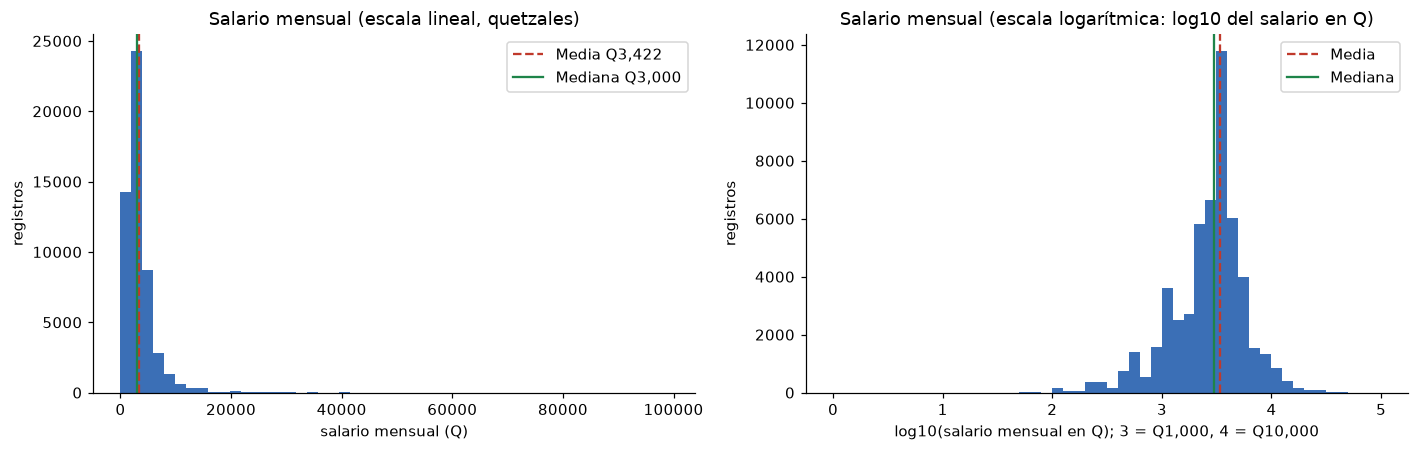

In [6]:
h_lin = exploracion.histograma(df, "salario_mensual", bins=50)
h_log = exploracion.histograma(df, "salario_mensual", bins=50, log10=True)
sal = exploracion.asimetria(df, "salario_mensual")

fig, (a, b) = plt.subplots(1, 2, figsize=(13, 4.2))
a.bar(h_lin["desde"], h_lin["registros"], width=(h_lin["hasta"] - h_lin["desde"]).iloc[0], align="edge", color="#3B6FB6")
a.axvline(sal["media"], color="#C0392B", ls="--", label=f"Media Q{sal['media']:,.0f}")
a.axvline(sal["mediana"], color="#1E8449", ls="-", label=f"Mediana Q{sal['mediana']:,.0f}")
a.set_title("Salario mensual (escala lineal, quetzales)")
a.set_xlabel("salario mensual (Q)")
a.set_ylabel("registros")
a.legend()

b.bar(h_log["desde"], h_log["registros"], width=(h_log["hasta"] - h_log["desde"]).iloc[0], align="edge", color="#3B6FB6")
b.axvline(np.log10(sal["media"]), color="#C0392B", ls="--", label="Media")
b.axvline(np.log10(sal["mediana"]), color="#1E8449", ls="-", label="Mediana")
b.set_title("Salario mensual (escala logarítmica: log10 del salario en Q)")
b.set_xlabel("log10(salario mensual en Q); 3 = Q1,000, 4 = Q10,000")
b.set_ylabel("registros")
b.legend()
plt.tight_layout()
plt.savefig(config.FIGURES / "02_histograma_salario.png", dpi=120, bbox_inches="tight")
plt.show()

In [7]:
print(f"Coeficiente de asimetría (skewness) del salario: {sal['asimetria']:.2f}")
print(f"Media Q{sal['media']:,.0f} vs. mediana Q{sal['mediana']:,.0f}: la media es {100 * (sal['media'] / sal['mediana'] - 1):+.1f} % respecto a la mediana (diferencia Q{sal['media'] - sal['mediana']:,.0f}).")
if sal["asimetria"] > 0.5:
    print("Conclusión: distribución asimétrica con cola larga hacia salarios altos (asimetría positiva).")
elif sal["asimetria"] < -0.5:
    print("Conclusión: distribución asimétrica con cola hacia salarios bajos (asimetría negativa).")
else:
    print("Conclusión: distribución aproximadamente simétrica.")

Coeficiente de asimetría (skewness) del salario: 6.00
Media Q3,422 vs. mediana Q3,000: la media es +14.1 % respecto a la mediana (diferencia Q422).
Conclusión: distribución asimétrica con cola larga hacia salarios altos (asimetría positiva).


**Interpretación.**

- **¿Simétrica o asimétrica?** Claramente **asimétrica a la derecha**: el coeficiente de asimetría es **6.0** y el histograma en quetzales muestra casi todos los registros por debajo de Q10,000 con una cola larga hasta Q99,000.
- **Media frente a mediana.** La media (Q3,422) supera a la mediana (Q3,000) en **Q422 (+14.1 %)**, porque los salarios altos la arrastran hacia arriba. La mediana representa mejor el salario típico.
- **Escala logarítmica.** En log10 la distribución se parece mucho más a una campana centrada cerca de 3.5 (unos Q3,000): la asimetría se debe sobre todo a que los salarios crecen de forma multiplicativa. Solo se usa para visualizar; el modelado usa el salario en quetzales.
- Los salarios altos y bajos **no se eliminaron**; su influencia se discutirá en el modelado (un modelo que minimiza el error cuadrático será sensible a esa cola).

## 4. Salario mediano por nivel educativo y por categoría ocupacional

Se usa la mediana (más robusta que la media) y se anota el número de registros de cada grupo.

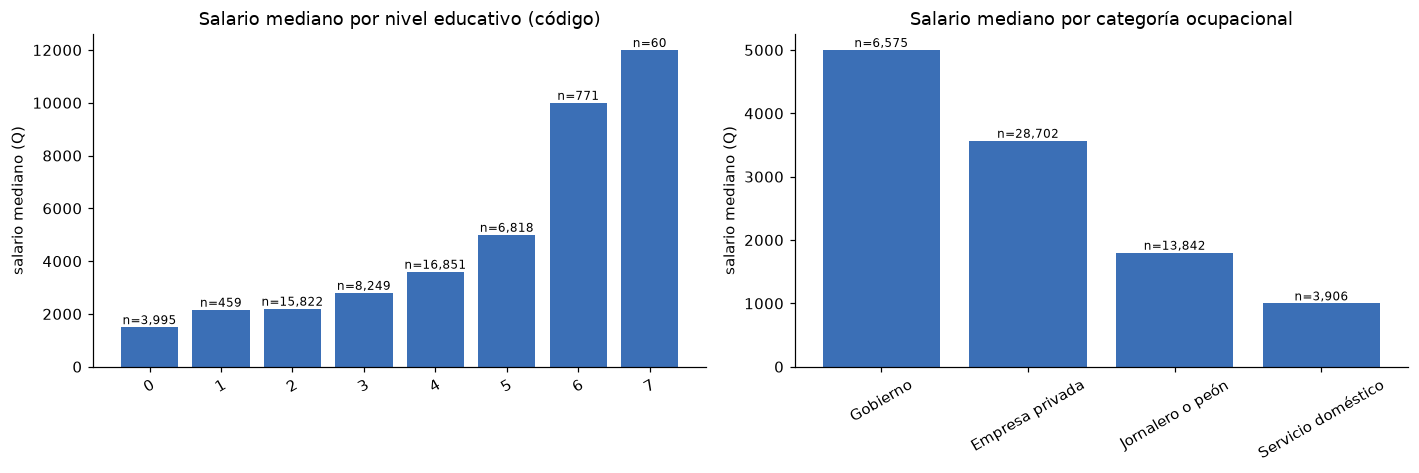

etiqueta  registros  salario_mediano  salario_medio
nivel_educativo       0                   0       3995         1,500.00       1,767.09
                      1                   1        459         2,160.00       2,241.90
                      2                   2      15822         2,200.00       2,307.96
                      3                   3       8249         2,800.00       2,730.20
                      4                   4      16851         3,600.00       3,796.41
                      5                   5       6818         5,000.00       5,965.30
                      6                   6        771        10,000.00      11,409.27
                      7                   7         60        12,000.00      14,452.27
categoria_ocupacional 0            Gobierno       6575         5,000.00       5,971.53
                      1     Empresa privada      28702         3,567.50       3,875.14
                      2    Jornalero o peón      13842         1,800.00       1,878.61
                      3  Servicio doméstico       3906         1,000.00       1,265.74
dominio               0                   1      22072         3,700.00       4,190.89
                      1                   2      20146         2,880.00       3,131.06
                      2                   3      10807         2,000.00       2,392.43

In [8]:
por_educ = rotular(exploracion.salario_por_grupo(df, "nivel_educativo"))
por_cat = rotular(exploracion.salario_por_grupo(df, "categoria_ocupacional"), CATEGORIAS)
por_dom = rotular(exploracion.salario_por_grupo(df, "dominio"))

fig, ejes = plt.subplots(1, 2, figsize=(13, 4.4))
for eje, t, titulo in [(ejes[0], por_educ, "Nivel educativo (código)"), (ejes[1], por_cat, "Categoría ocupacional")]:
    barras = eje.bar(t["etiqueta"], t["salario_mediano"], color="#3B6FB6")
    for b, n in zip(barras, t["registros"]):
        eje.text(b.get_x() + b.get_width() / 2, b.get_height(), f"n={n:,}", ha="center", va="bottom", fontsize=8)
    eje.set_title(f"Salario mediano por {titulo.lower()}")
    eje.set_ylabel("salario mediano (Q)")
    eje.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(config.FIGURES / "02_salario_mediano_grupos.png", dpi=120, bbox_inches="tight")
plt.show()

tabla_grupos = pd.concat({
    "nivel_educativo": por_educ, "categoria_ocupacional": por_cat, "dominio": por_dom,
})[["etiqueta", "registros", "salario_mediano", "salario_medio"]]
tabla_grupos.to_csv(config.TABLES / "02_salario_por_grupo_2025.csv")
tabla_grupos

In [9]:
def rango(t, nombre):
    alto, bajo = t.loc[t["salario_mediano"].idxmax()], t.loc[t["salario_mediano"].idxmin()]
    print(f"{nombre}: mediana más alta en '{alto['etiqueta']}' (Q{alto['salario_mediano']:,.0f}, n={alto['registros']:,}) y más baja en '{bajo['etiqueta']}' (Q{bajo['salario_mediano']:,.0f}, n={bajo['registros']:,}); razón {alto['salario_mediano'] / bajo['salario_mediano']:.1f}.")

rango(por_educ, "Nivel educativo")
rango(por_cat, "Categoría ocupacional")
rango(por_dom, "Dominio")

Nivel educativo: mediana más alta en '7' (Q12,000, n=60) y más baja en '0' (Q1,500, n=3,995); razón 8.0.
Categoría ocupacional: mediana más alta en 'Gobierno' (Q5,000, n=6,575) y más baja en 'Servicio doméstico' (Q1,000, n=3,906); razón 5.0.
Dominio: mediana más alta en '1' (Q3,700, n=22,072) y más baja en '3' (Q2,000, n=10,807); razón 1.9.


**Interpretación.** El salario mediano **crece con el nivel educativo** de forma casi continua: Q1,500 en el código 0 (ninguno), Q2,200 en el 2, Q3,600 en el 4, Q5,000 en el 5 y Q10,000–Q12,000 en los códigos 6 y 7 (estos últimos con pocos registros: 771 y 60). Entre categorías ocupacionales, el **empleo de gobierno** tiene la mediana más alta (Q5,000), seguido de empresa privada (Q3,568), jornaleros (Q1,800) y **servicio doméstico** (Q1,000): la razón entre el extremo alto y el bajo es de 5 a 1. Por dominio, la mediana va de Q3,700 (dominio 1) a Q2,000 (dominio 3). Son **asociaciones descriptivas**: no muestran que estudiar más *cause* un salario mayor ni indican cuánto debería ganar una persona, y las variables se mezclan entre sí (el empleo de gobierno concentra más educación).

## 5. Tamaño de la muestra y salario mediano por trimestre

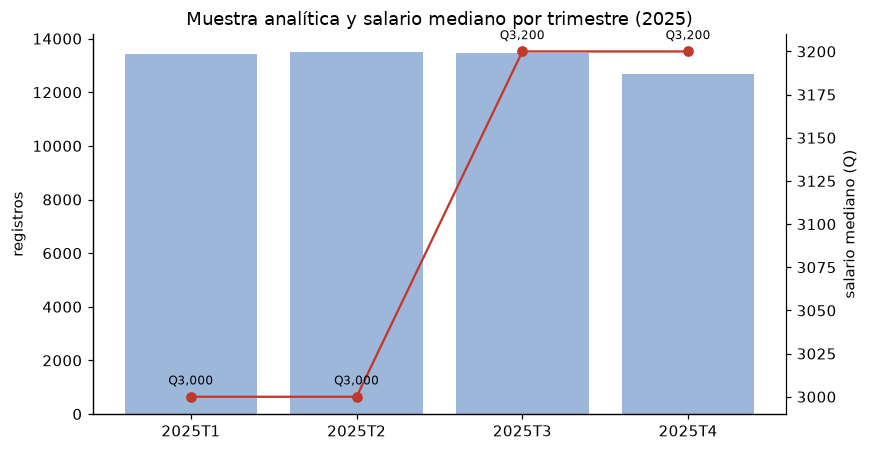

,periodo_archivo,registros,salario_mediano,salario_medio
0,2025T1,13419,"3,000.00","3,315.63"
1,2025T2,13492,"3,000.00","3,364.57"
2,2025T3,13450,"3,200.00","3,469.07"
3,2025T4,12664,"3,200.00","3,544.57"


In [10]:
trim = exploracion.resumen_por_trimestre(df)
trim.to_csv(config.TABLES / "02_resumen_trimestre_2025.csv", index=False)

fig, a = plt.subplots(figsize=(8, 4.2))
a.bar(trim["periodo_archivo"], trim["registros"], color="#9DB7DB", label="Registros analíticos")
a.set_ylabel("registros")
b = a.twinx()
b.plot(trim["periodo_archivo"], trim["salario_mediano"], color="#C0392B", marker="o", label="Salario mediano")
b.set_ylabel("salario mediano (Q)")
b.spines["right"].set_visible(True)
a.set_title("Muestra analítica y salario mediano por trimestre (2025)")
for x, y in zip(trim["periodo_archivo"], trim["salario_mediano"]):
    b.annotate(f"Q{y:,.0f}", (x, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(config.FIGURES / "02_muestra_y_mediana_trimestre.png", dpi=120, bbox_inches="tight")
plt.show()
trim

In [11]:
variacion_n = 100 * (trim["registros"].max() / trim["registros"].min() - 1)
variacion_m = 100 * (trim["salario_mediano"].max() / trim["salario_mediano"].min() - 1)
print(f"El tamaño de la muestra varía {variacion_n:.1f} % entre el trimestre más pequeño y el más grande.")
print(f"El salario mediano varía {variacion_m:.1f} % entre el trimestre más bajo y el más alto.")

El tamaño de la muestra varía 6.5 % entre el trimestre más pequeño y el más grande.
El salario mediano varía 6.7 % entre el trimestre más bajo y el más alto.


**Interpretación.** El tamaño de la muestra analítica es estable: entre 12,664 (2025T4) y 13,492 (2025T2) registros, una variación de 6.5 %. El salario mediano es de Q3,000 en los dos primeros trimestres y de **Q3,200** en el tercero y el cuarto (+6.7 %), y la media sube de Q3,316 a Q3,545. Hay un leve aumento en la segunda mitad del año, pero es pequeño, no se ha medido su incertidumbre y parte de las personas se repite entre trimestres, así que no permite concluir que los salarios cambiaron.

## 6. Correlaciones entre variables numéricas

Correlación de Pearson calculada con `VectorAssembler` y `Correlation.corr` de `pyspark.ml.stat`, sobre **todos** los registros elegibles de 2025.

In [12]:
corr = exploracion.matriz_correlacion(df)
etiquetas = [exploracion.ETIQUETAS[v] for v in corr.columns]
corr_rotulada = corr.set_axis(etiquetas, axis=0).set_axis(etiquetas, axis=1)
corr_rotulada.to_csv(config.TABLES / "02_correlacion_2025.csv")
corr_rotulada.style.format("{:.3f}").background_gradient(cmap="RdBu_r", vmin=-1, vmax=1)

,Salario mensual (Q),Edad (años),Antigüedad (años),Horas semanales
Salario mensual (Q),1.000,0.147,0.180,0.076
Edad (años),0.147,1.000,0.487,-0.105
Antigüedad (años),0.180,0.487,1.000,-0.062
Horas semanales,0.076,-0.105,-0.062,1.000


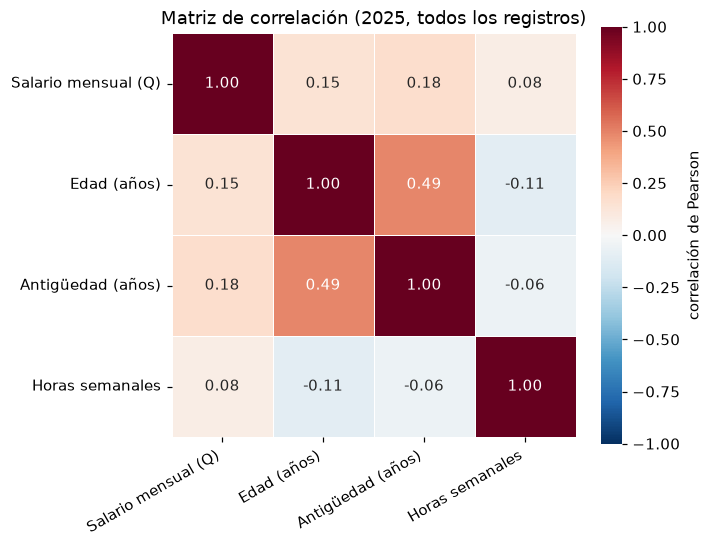

In [13]:
fig, eje = plt.subplots(figsize=(6.5, 5.2))
sns.heatmap(corr_rotulada, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, square=True,
            linewidths=.5, cbar_kws={"label": "correlación de Pearson"}, ax=eje)
eje.set_title("Matriz de correlación (2025, todos los registros)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(config.FIGURES / "02_mapa_calor_correlacion.png", dpi=120, bbox_inches="tight")
plt.show()

In [14]:
con_salario = corr["salario_mensual"].drop("salario_mensual").sort_values(key=np.abs, ascending=False)
for v, r in con_salario.items():
    fuerza = "muy débil" if abs(r) < .1 else "débil" if abs(r) < .3 else "moderada" if abs(r) < .5 else "fuerte"
    print(f"Salario vs. {exploracion.ETIQUETAS[v]}: r = {r:+.3f} ({fuerza}, r² = {r ** 2:.3f})")
print(f"\nMayor asociación lineal con el salario: {exploracion.ETIQUETAS[con_salario.index[0]]}.")
r_ea = corr.loc["edad", "antiguedad"]
print(f"Edad vs. antigüedad: r = {r_ea:+.3f}")

Salario vs. Antigüedad (años): r = +0.180 (débil, r² = 0.032)
Salario vs. Edad (años): r = +0.147 (débil, r² = 0.022)
Salario vs. Horas semanales: r = +0.076 (muy débil, r² = 0.006)

Mayor asociación lineal con el salario: Antigüedad (años).
Edad vs. antigüedad: r = +0.487


**Interpretación.**

- **Asociación lineal con el salario.** Las tres correlaciones son **débiles**: antigüedad **r = 0.18** (la mayor), edad r = 0.15 y horas r = 0.08. La antigüedad sola explica linealmente apenas 3.2 % de la variación del salario (r² = 0.032). Ninguna variable numérica por sí sola explica bien el salario, por eso los modelos incluyen además nivel educativo, categoría ocupacional y dominio, que en la sección 4 mostraron diferencias de mediana mucho mayores.
- **Edad y antigüedad.** Sí hay relación: **r = 0.49**, positiva y moderada. Quienes tienen más edad han tenido más tiempo para acumular antigüedad, pero los cambios de empleo la debilitan (hay personas mayores con poca antigüedad). No es tan alta como para que una variable sustituya a la otra.
- **Precauciones.** Pearson mide solo asociación **lineal** y es sensible a valores extremos, y el salario tiene cola derecha; una relación no lineal puede quedar subestimada. Las correlaciones no demuestran causalidad, y las observaciones repetidas de una misma persona no son independientes.

In [15]:
df.unpersist()
spark.stop()